In [ ]:
import numpy as np
import matplotlib.pyplot as plt

<h1> QUESTION 1 <h1>

In [ ]:
x = [1, 2, 3, 4]
h = [0, 1, 0.5, 1]

x = np.array(x)
h = np.array(h)
N = len(x)

<h3> --- Linear Convolution --- <h3>



In [ ]:
def linear_conv_dir(x, h):
    M = len(x)
    N = len(h)
    y = np.zeros(M + N - 1)
    for n in range(M + N - 1):
        for k in range(M):
            if 0 <= n - k < N:
                y[n] += x[k] * h[n - k]
    return y

y_linear_direct = linear_conv_dir(x, h)
print("Linear Convolution (Direct Formula):", y_linear_direct)

Linear Convolution (Direct Formula): [0.  1.  2.5 5.  7.5 5.  4. ]


In [ ]:
# Using numpy.convolve()
y_linear_numpy = np.convolve(x, h)
print("Linear Convolution (numpy.convolve):", y_linear_numpy)

Linear Convolution (numpy.convolve): [0.  1.  2.5 5.  7.5 5.  4. ]


<h3> --- Circular Convolution ---<h3>

In [ ]:
def circular_conv_direct(x, h):
    N = len(x)
    y = np.zeros(N)
    for n in range(N):
        for k in range(N):
            y[n] += x[k] * h[(n - k) % N]
    return y

y_circular_direct = circular_conv_direct(x, h)
print("Circular Convolution (Direct Formula):", y_circular_direct)

Circular Convolution (Direct Formula): [7.5 6.  6.5 5. ]


In [ ]:
# DFT method using numpy.fft.fft()
X = np.fft.fft(x)
H = np.fft.fft(h)
Y = X * H
y_circular_fft = np.fft.ifft(Y)
y_circular_fft = np.real(y_circular_fft)
print("Circular Convolution (DFT Method):", y_circular_fft)

Circular Convolution (DFT Method): [7.5 6.  6.5 5. ]


<h3> --- Comparison ---<h3>

In [ ]:
print("\nComparison:")
print("Linear Convolution (Direct):", y_linear_direct)
print("Linear Convolution (numpy):", y_linear_numpy)
print("Circular Convolution (Direct):", y_circular_direct)
print("Circular Convolution (DFT):", y_circular_fft)


Comparison:
Linear Convolution (Direct): [0.  1.  2.5 5.  7.5 5.  4. ]
Linear Convolution (numpy): [0.  1.  2.5 5.  7.5 5.  4. ]
Circular Convolution (Direct): [7.5 6.  6.5 5. ]
Circular Convolution (DFT): [7.5 6.  6.5 5. ]


<h1> QUESTION 2 <h1>

In [ ]:
x = np.array([3, 1, 0, 2, 5])
y = np.array([1, 2, 3, 4, 5])

<h3>direct formula<h3>

In [ ]:
def auto_correlation(signal):
    N = len(signal)
    result = np.zeros(2 * N - 1)
    for l in range(-N + 1, N):
        for i in range(N):
            if 0 <= i + l < N:
                result[l + N - 1] += signal[i] * signal[i + l]
    return result

auto_corr_x = auto_correlation(x)

<h3>using numpy.correlate<h3>

In [ ]:
auto_corr_x_np = np.correlate(x, x, mode='full')
cross_corr_xy = np.correlate(x, y, mode='full')

In [ ]:
print("Auto-correlation (Direct):", auto_corr_x)
print("Auto-correlation (numpy):", auto_corr_x_np)
print("Cross-correlation:", cross_corr_xy)

Auto-correlation (Direct): [15. 11.  2. 13. 39. 13.  2. 11. 15.]
Auto-correlation (numpy): [15 11  2 13 39 13  2 11 15]
Cross-correlation: [15 17 13 19 38 27 19 12  5]


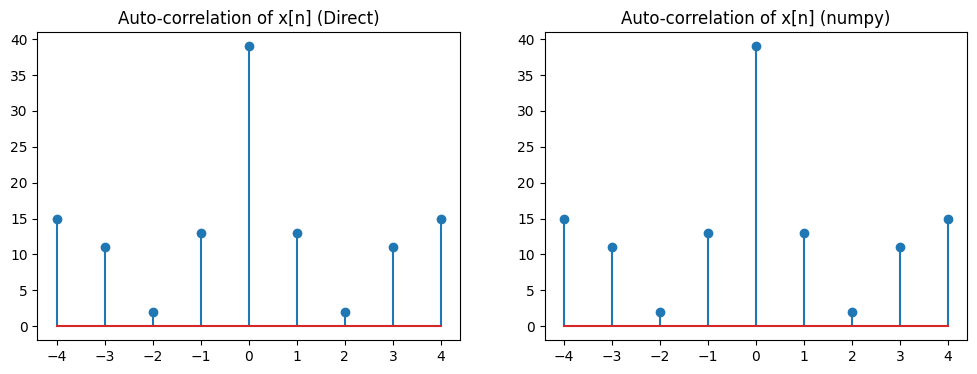

In [ ]:
ll = np.arange(-len(x) + 1, len(x))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(ll, auto_corr_x)
plt.title("Auto-correlation of x[n] (Direct)")

plt.subplot(1, 2, 2)
plt.stem(ll, auto_corr_x_np)
plt.title("Auto-correlation of x[n] (numpy)")

plt.show()

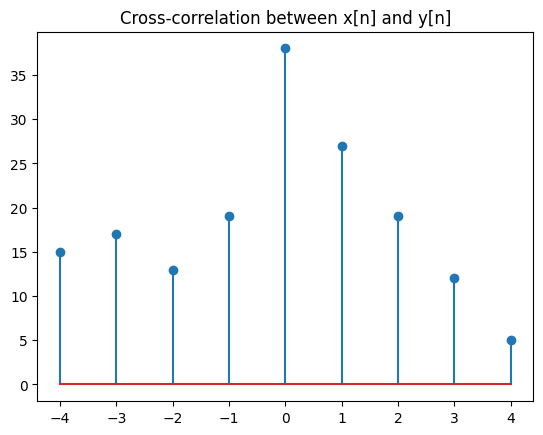

In [ ]:
ll_cross = np.arange(-len(x) + 1, len(y))
plt.figure()
plt.stem(ll_cross, cross_corr_xy)
plt.title("Cross-correlation between x[n] and y[n]")
plt.show()


<h1> QUESTION 3 <h1>

In [ ]:
import sympy as sp

In [114]:
def Z_transform(signal, n):
    z = sp.symbols('z')
    a = 0.5
    X_z = 1 / (1 - a * z**(-1))

    return sp.simplify(X_z)


def inverse_Z_transform(X_z):
    z = sp.symbols('z')
    a = 0.5
    n = sp.symbols('n')

    x_n = a**n
    return x_n

In [115]:
# Function to plot pole-zero diagram
def plot_pole_zero(poles, zeros):
    fig, ax = plt.subplots()

    ax.plot(np.real(poles), np.imag(poles), 'rx', markersize=10, label='Poles')
    if zeros:
        ax.plot(np.real(zeros), np.imag(zeros), 'bo', markersize=10, label='Zeros')

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend()

    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.set_title('Pole-Zero Diagram')

    # Plot limits
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])

    plt.show()


In [116]:
def roc(X_z):
    z = sp.symbols('z')

    poles = sp.solve(sp.denom(X_z), z)
    poles_numeric = [complex(p.evalf()) for p in poles]

    roc_radius = max(abs(p) for p in poles_numeric)
    roc = f'ROC: |z| > {roc_radius}'  # formatted string to display the value

    return poles_numeric, roc

In [117]:
n = sp.symbols('n')
x_n = (0.5)**n

In [118]:
# Compute Z-Transform
X_z = Z_transform(x_n, n)

print("Z-Transform of x[n]:", X_z)

Z-Transform of x[n]: z/(z - 0.5)


In [119]:

xn_inverse = inverse_Z_transform(X_z)

print("Inverse Z-Transform of X(z):", xn_inverse)

Inverse Z-Transform of X(z): 0.5**n


In [120]:
poles, roc = roc(X_z)

# Display the ROC
print("Poles:", poles)
print(roc)



Poles: [(0.5+0j)]
ROC: |z| > 0.5


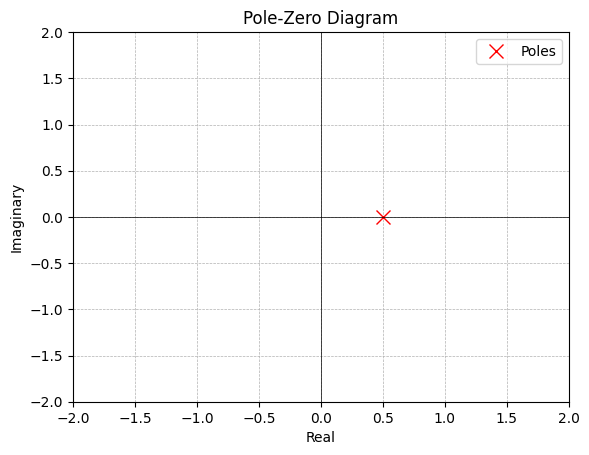

In [121]:
plot_pole_zero(poles, [])

<h1> QUESTION 4 <h1>

In [ ]:
from scipy.signal import lfilter

In [ ]:
n = np.arange(0, 11)
x = np.zeros(len(n))
x[0] = 1
print("Input signal x[n]:", x)

Input signal x[n]: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [92]:
# Direct iterative computation
y_direct = np.zeros(len(n))
y_direct[0] = x[0]

for i in range(1, len(n)):
    y_direct[i] = 0.5 * y_direct[i-1] + x[i] + 2 * (x[i-1] if i-1 >= 0 else 0)

print("Output y[n]:", y_direct)

Output y[n]: [ 1.          3.20710678  3.01776695  0.8017767  -2.01332521 -3.71376939
 -3.27109826 -0.92844235]


In [93]:
# Using scipy.signal.lfilter()
b = [1, 2]
a = [1, -0.5]

y_lfilter = lfilter(b, a, x)
print("Output y[n]:", y_lfilter)

Output y[n]: [ 1.          3.20710678  3.01776695  0.8017767  -2.01332521 -3.71376939
 -3.27109826 -0.92844235]



Comparison:
Difference between Direct and lfilter: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


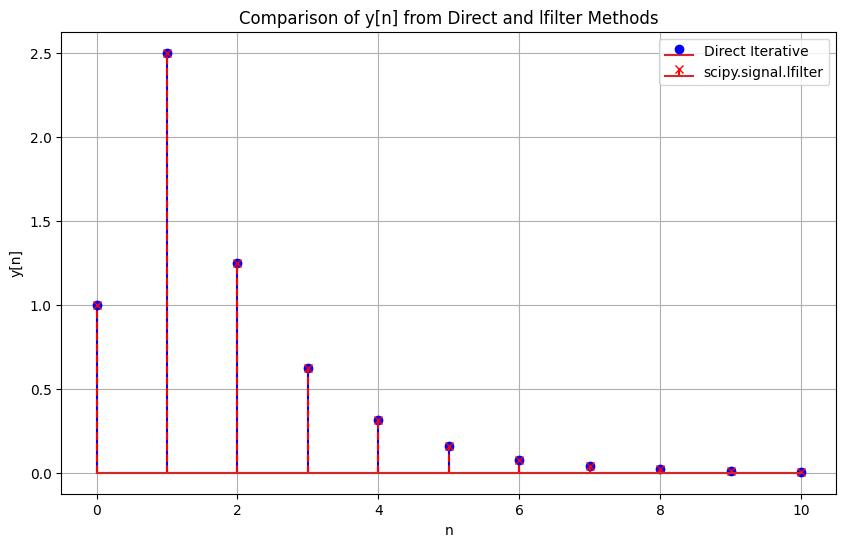

In [ ]:
# Compare the results
print("\nComparison:")
print("Difference between Direct and lfilter:", np.abs(y_direct - y_lfilter))

# Plot the results
plt.figure(figsize=(10, 6))
plt.stem(n, y_direct, linefmt='b-', markerfmt='bo', label='Direct Iterative')
plt.stem(n, y_lfilter, linefmt='r--', markerfmt='rx', label='scipy.signal.lfilter')
plt.title("Comparison of y[n] from Direct and lfilter Methods")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.legend()
plt.grid(True)
plt.show()

<h1> QUESTION 5 <h1>

In [ ]:
N = 8
n = np.arange(N)

x = np.cos(2 * np.pi * n / N)
print("Periodic sequence x[n]:", x)

Periodic sequence x[n]: [ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -7.07106781e-01
 -1.00000000e+00 -7.07106781e-01 -1.83697020e-16  7.07106781e-01]


In [94]:
# Direct formula implementation of DFS coefficients
def dfs_direct(x, N):
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X

X_direct = dfs_direct(x, N)
print("DFS Coefficients:", X_direct)

DFS Coefficients: [-5.55111512e-16+0.00000000e+00j  4.00000000e+00-3.33066907e-16j
 -3.35876614e-16-1.11022302e-16j  6.66133815e-16-3.33066907e-16j
  1.11022302e-16-4.89858720e-16j  1.66533454e-15-1.05471187e-15j
  1.07628411e-15-7.77156117e-16j  4.00000000e+00+4.55191440e-15j]


In [95]:
# Compute DFS coefficients using numpy.fft.fft()
X_fft = np.fft.fft(x)
print("DFS Coefficients:", X_fft)

DFS Coefficients: [-3.44509285e-16+0.00000000e+00j  4.00000000e+00-4.66973965e-16j
  1.22464680e-16+0.00000000e+00j  0.00000000e+00+2.28847549e-17j
  9.95799250e-17+0.00000000e+00j  0.00000000e+00-2.28847549e-17j
  1.22464680e-16+0.00000000e+00j  4.00000000e+00+4.66973965e-16j]


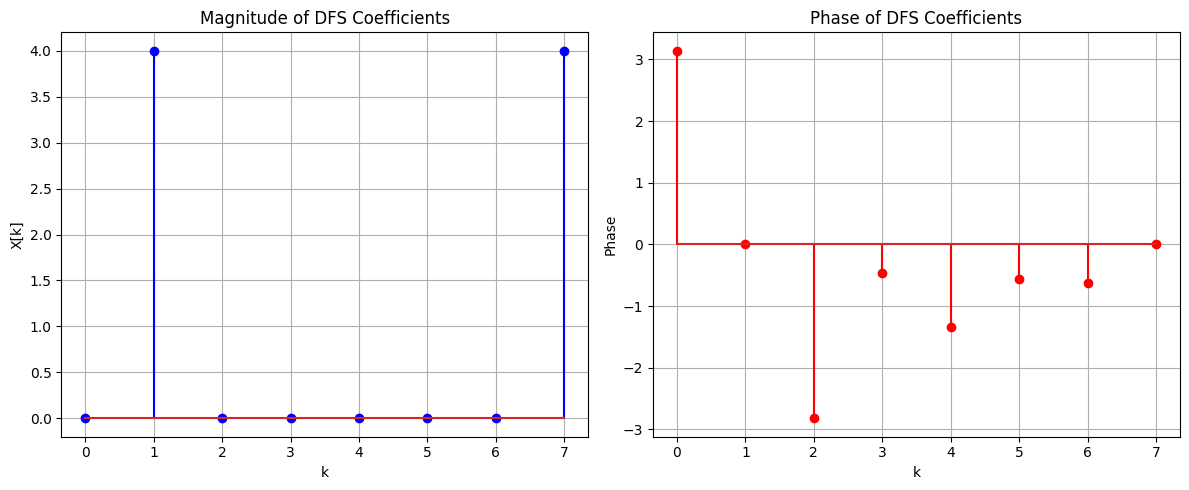

In [96]:
# Plot magnitude and phase of DFS coefficients
k = np.arange(N)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.stem(k, np.abs(X_direct), linefmt='b-', markerfmt='bo')
plt.title("Magnitude of DFS Coefficients")
plt.xlabel("k")
plt.ylabel("X[k]")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(k, np.angle(X_direct), linefmt='r-', markerfmt='ro')
plt.title("Phase of DFS Coefficients")
plt.xlabel("k")
plt.ylabel("Phase")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\nComparison:")
print("Difference between Direct and fft:", np.abs(X_direct - X_fft))



Comparison:
Difference between Direct and fft: [2.10602227e-16 1.33907057e-16 4.71595900e-16 7.55272034e-16
 4.89992340e-16 1.95908303e-15 1.23034269e-15 4.18038267e-15]
